## Validation Viz, Qual for SM

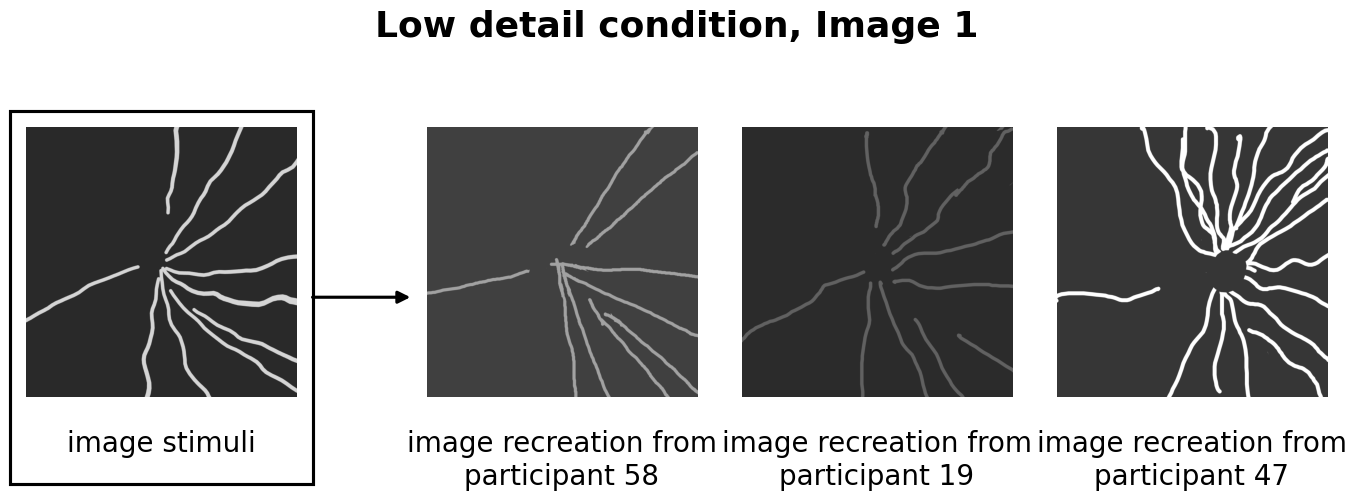

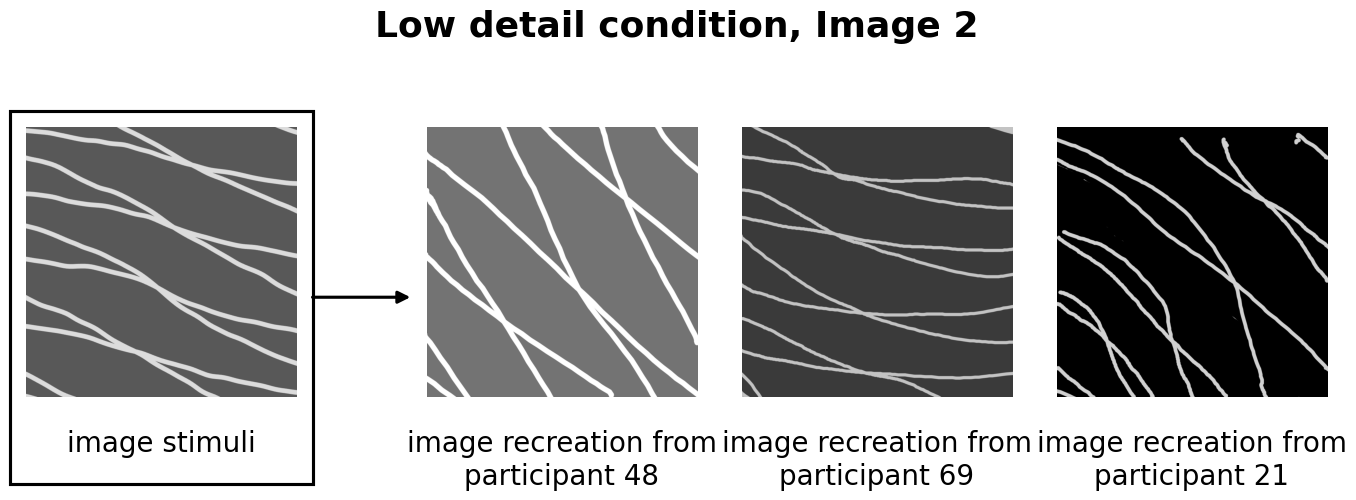

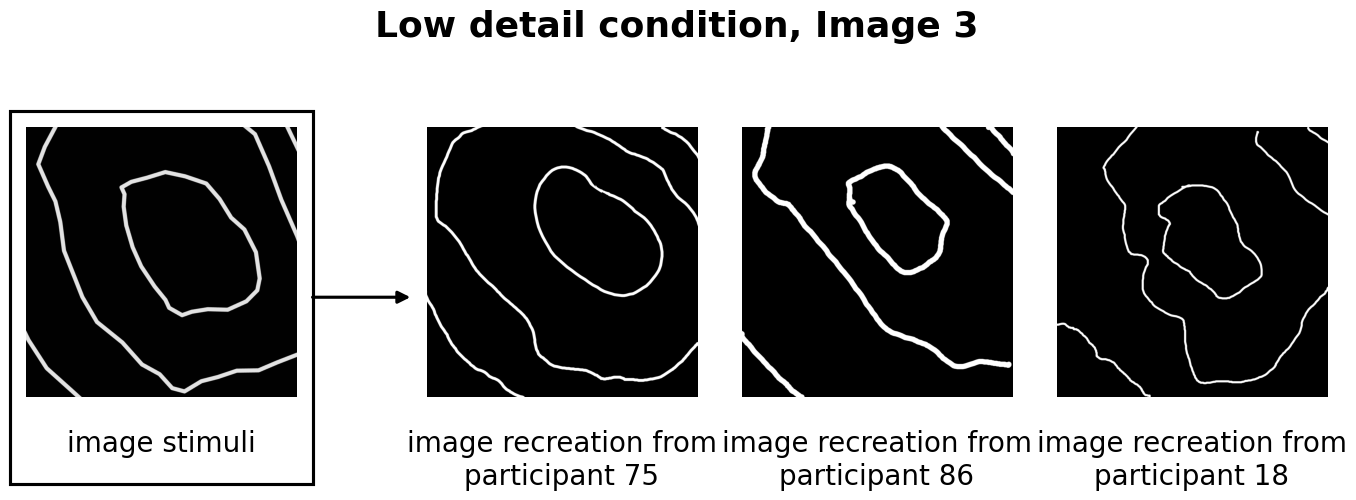

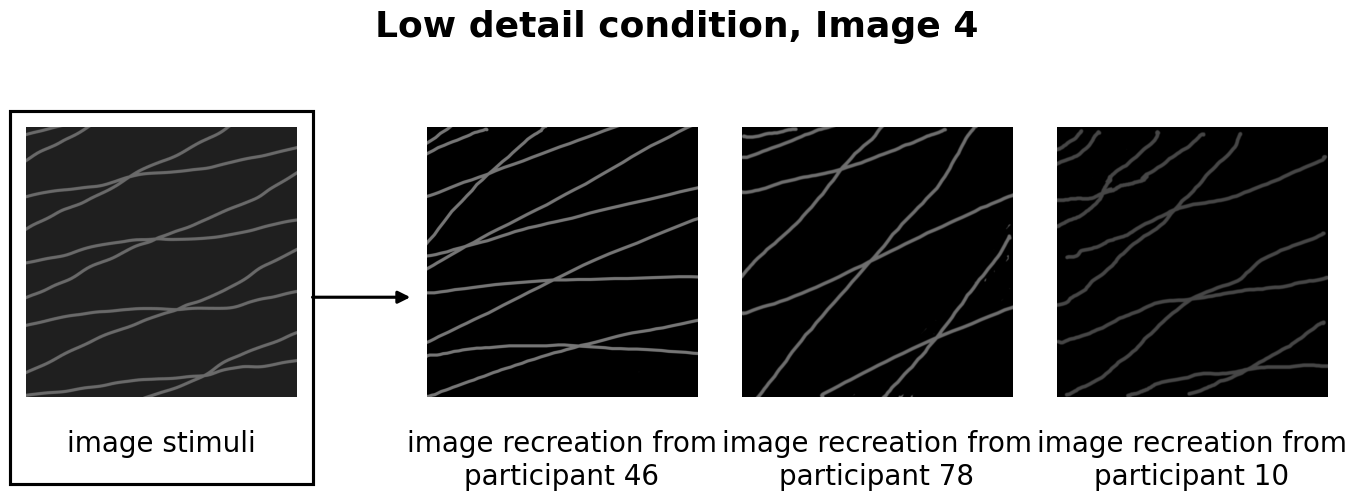

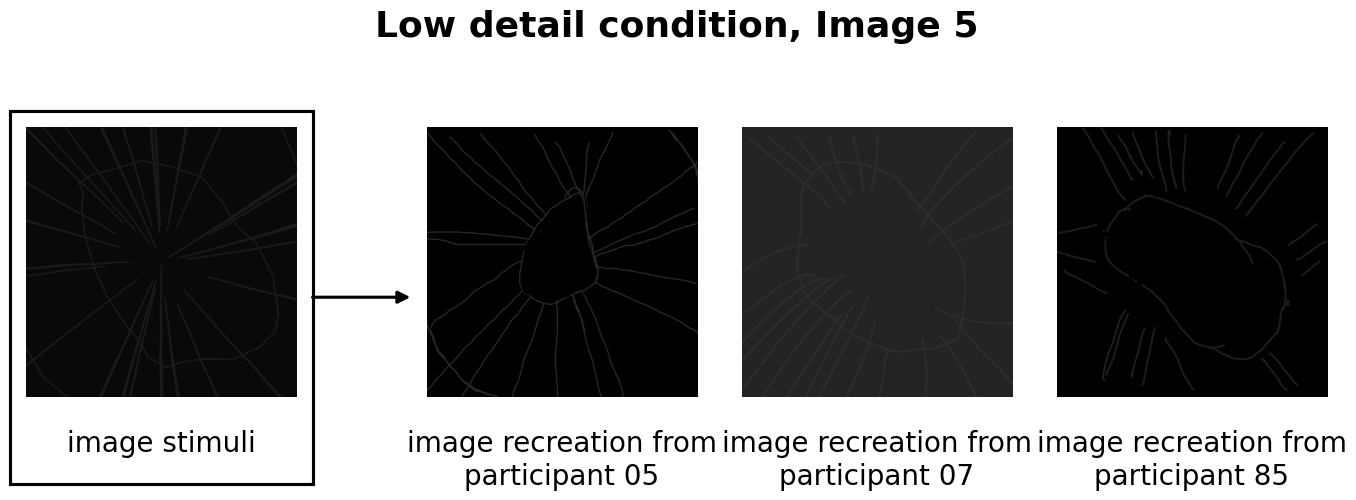

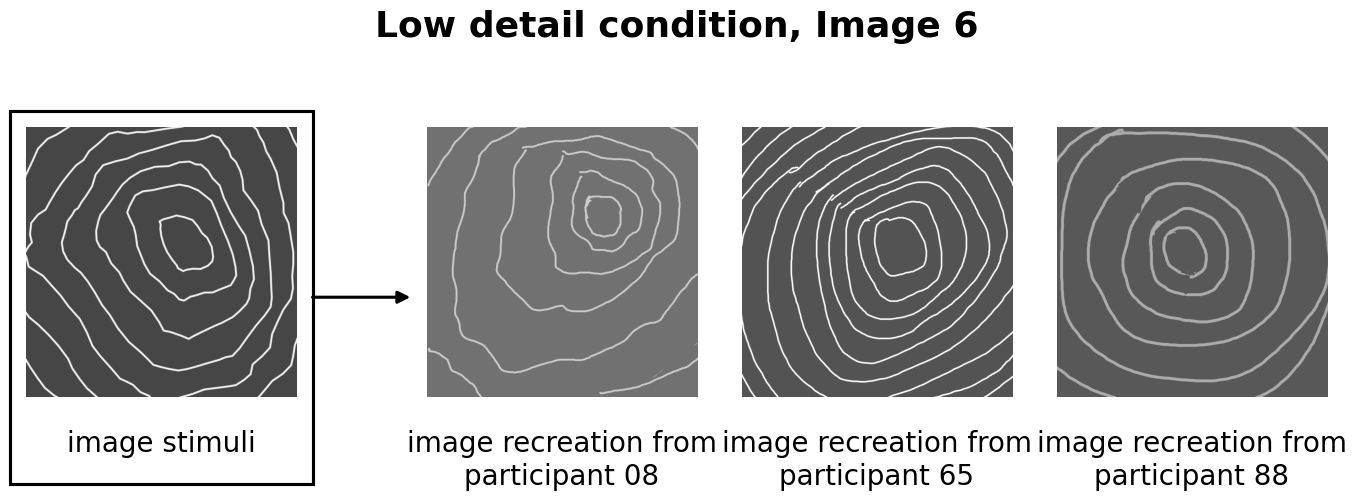

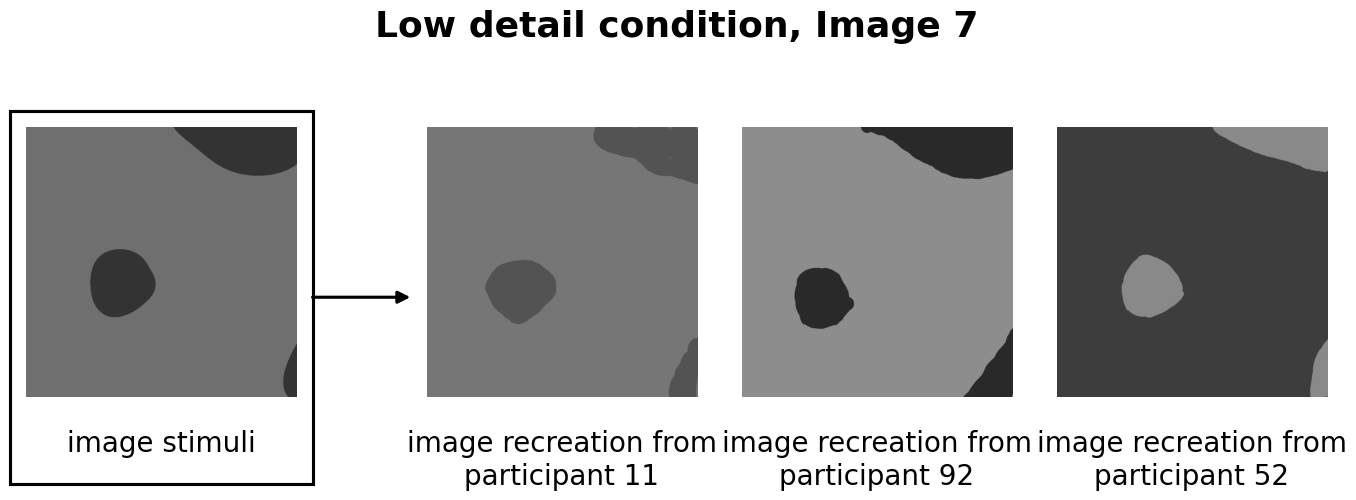

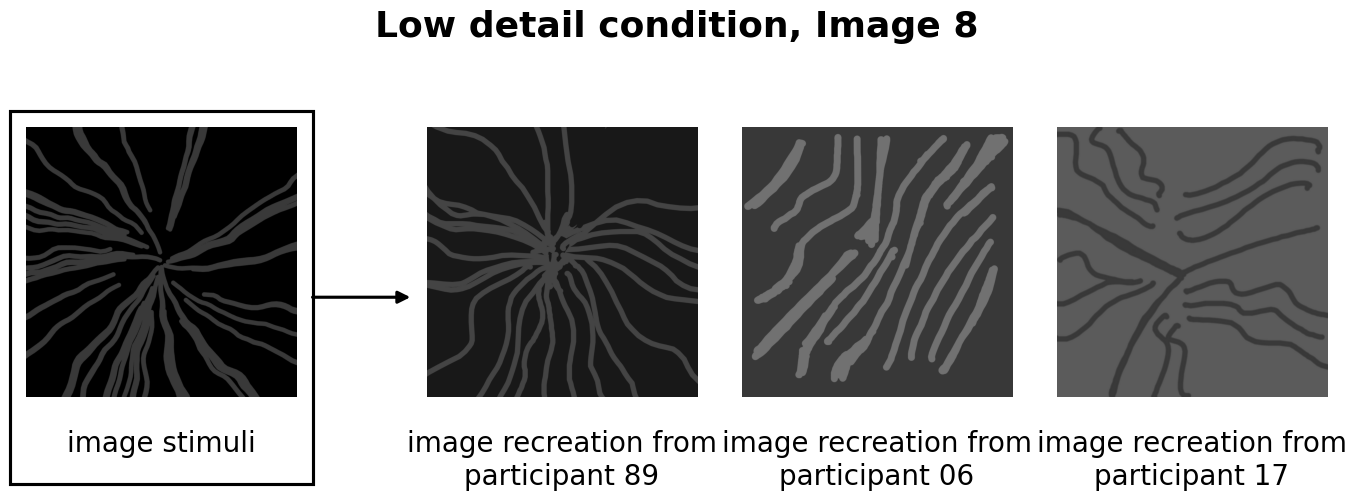

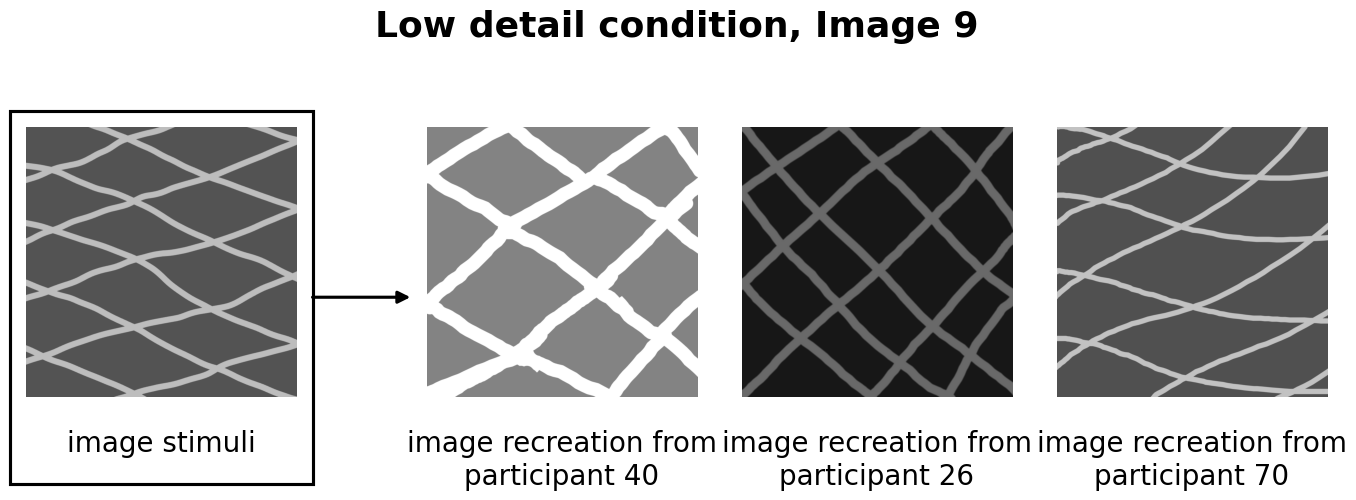

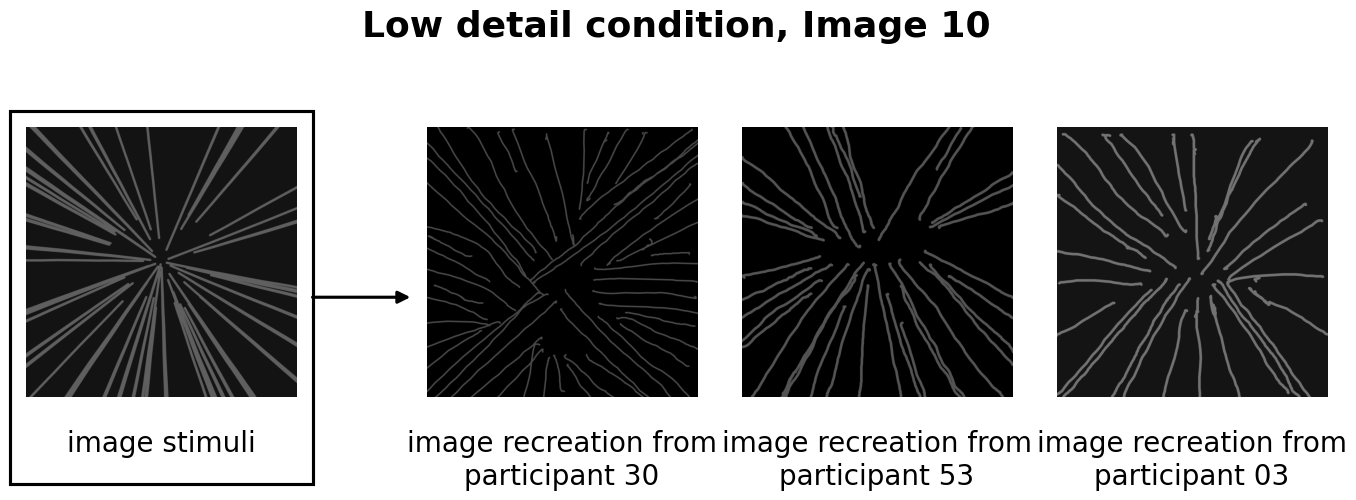

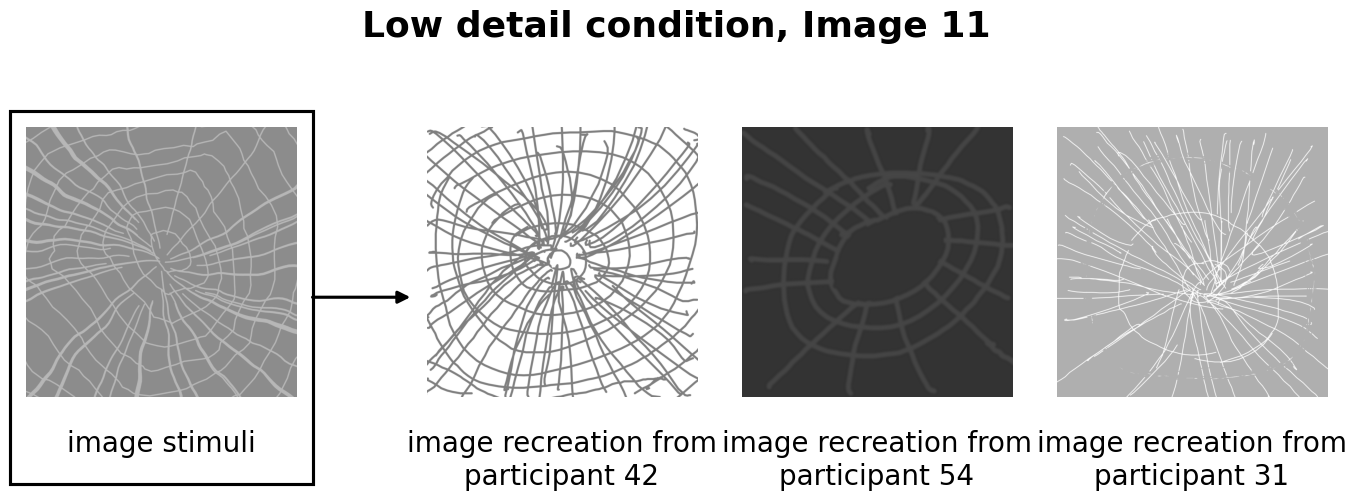

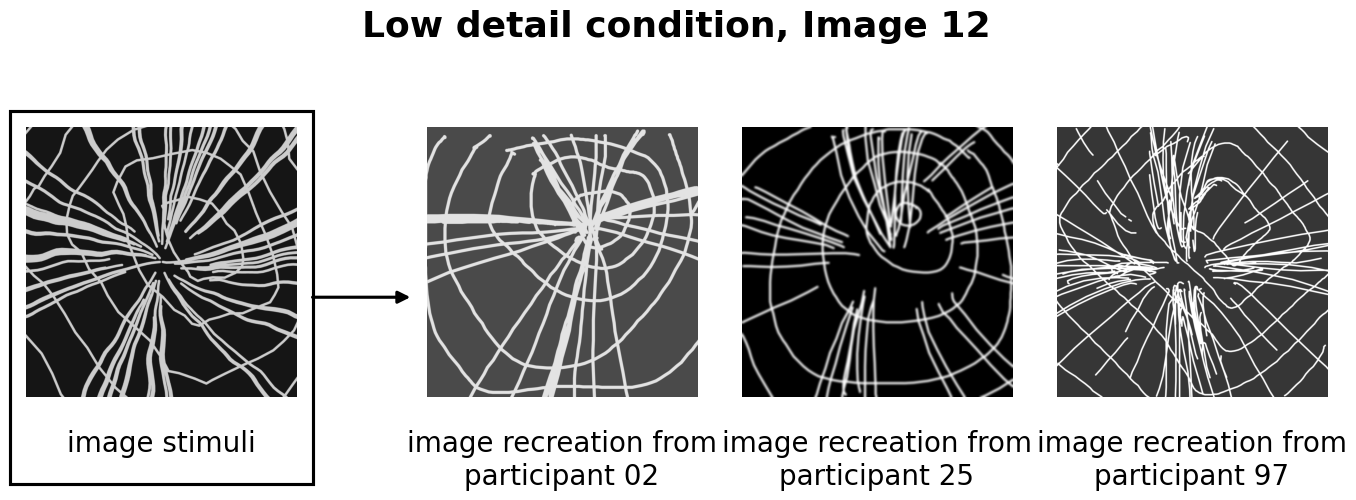

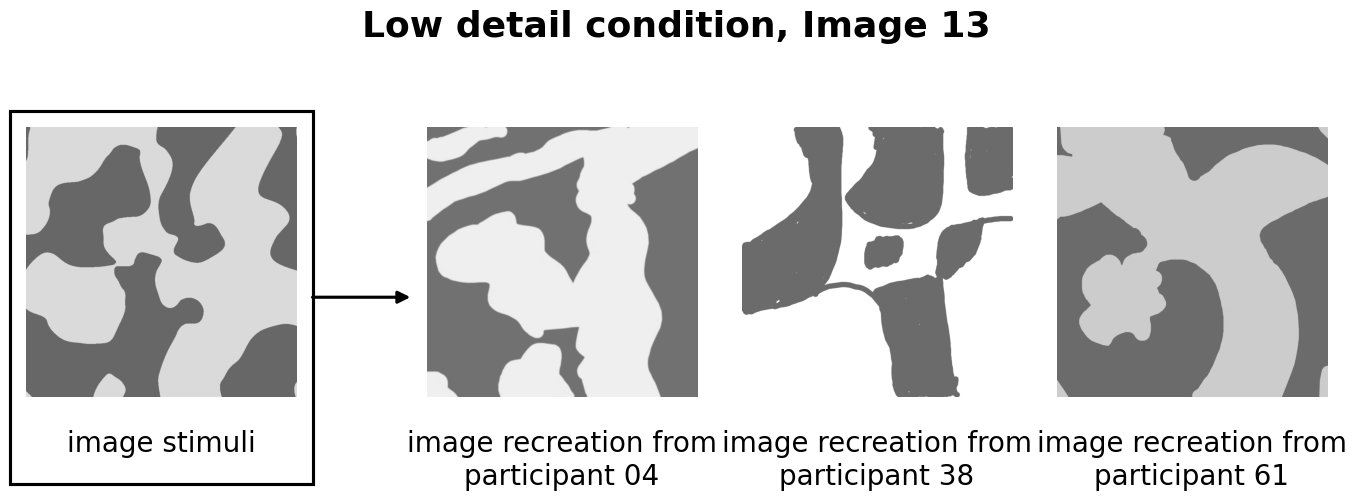

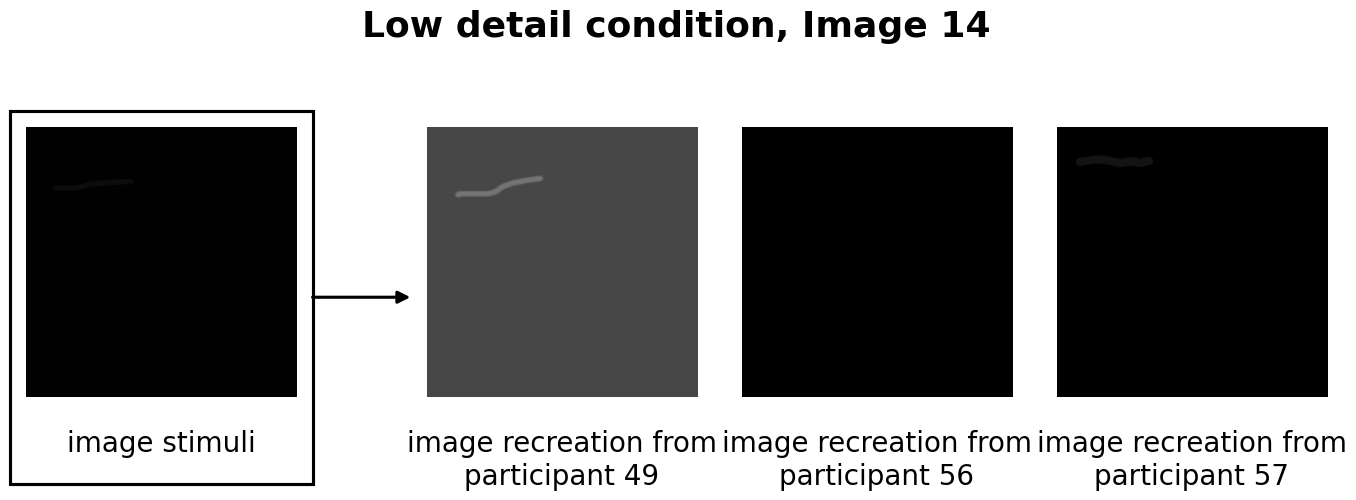

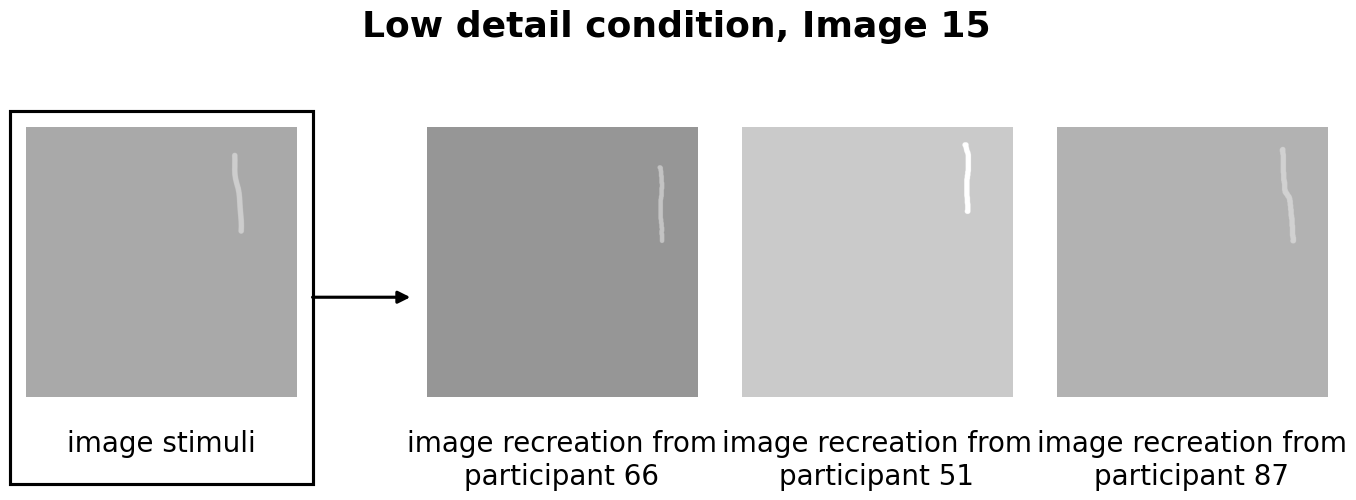

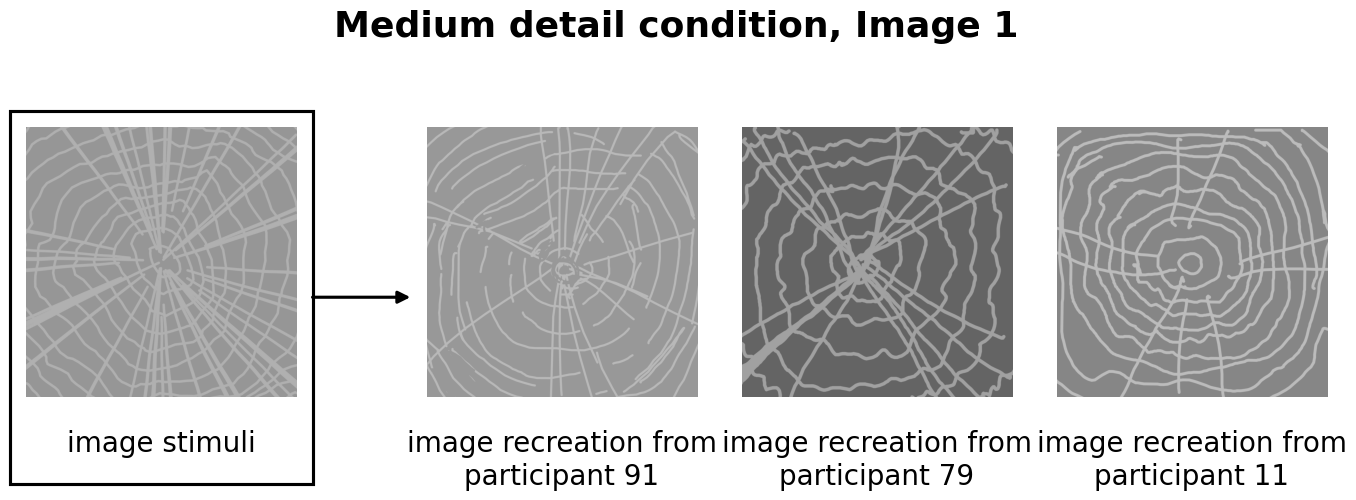

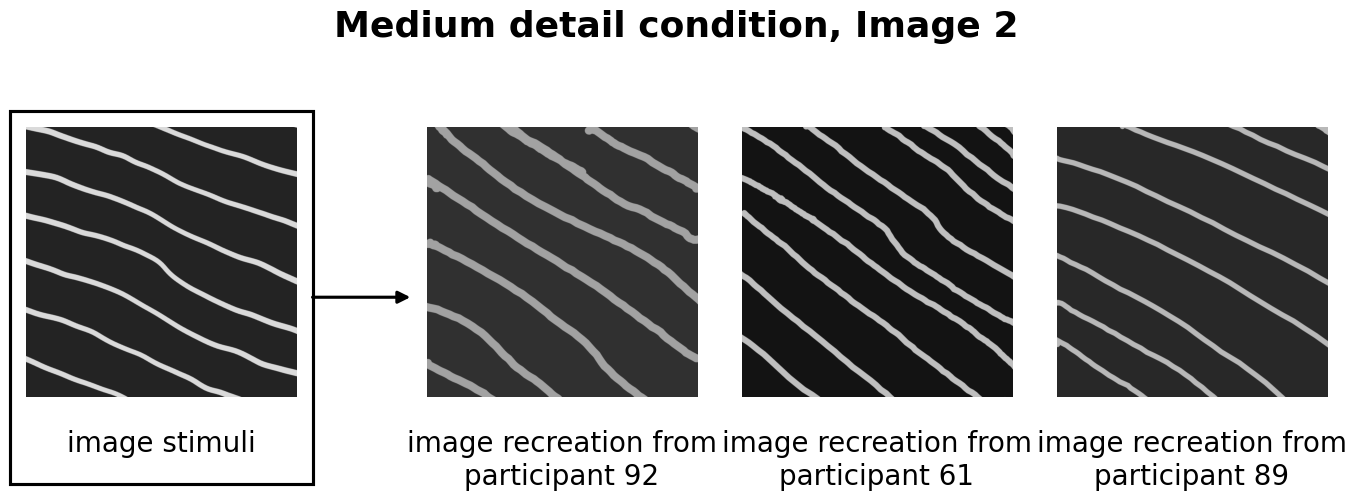

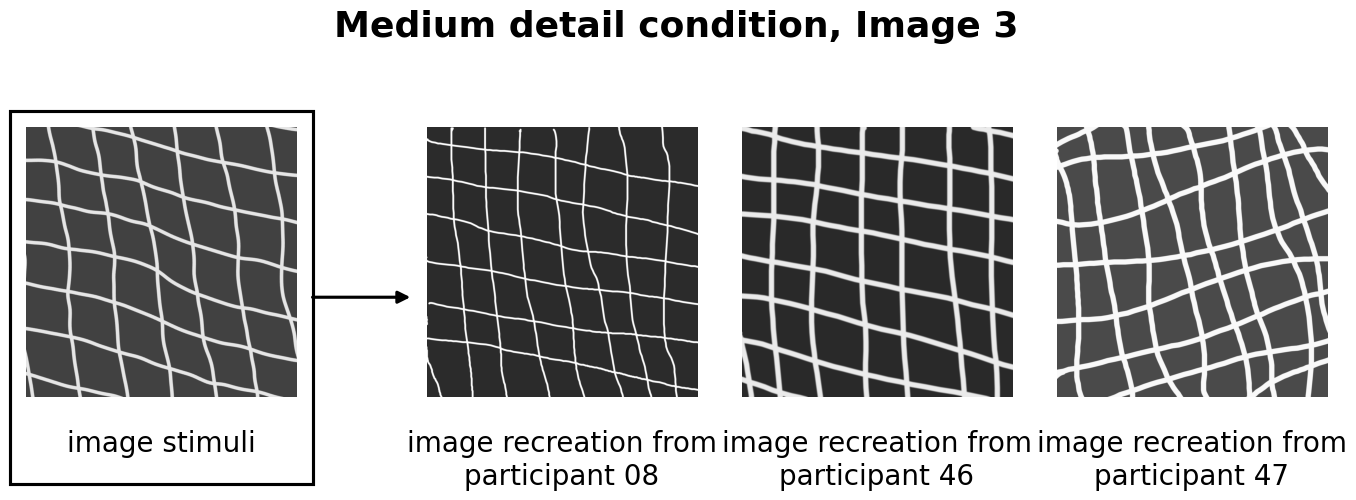

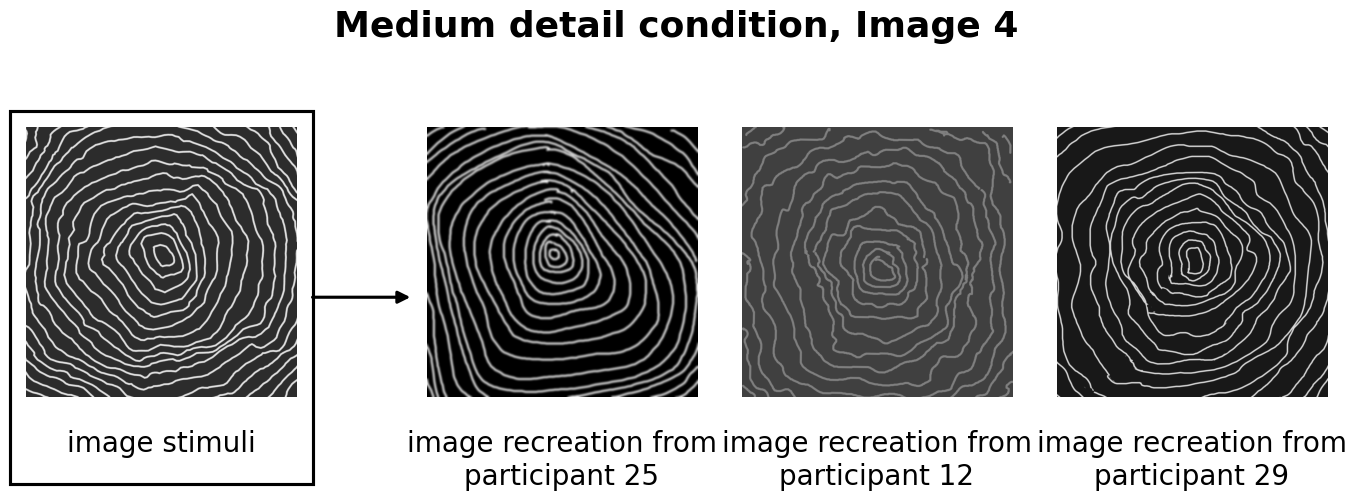

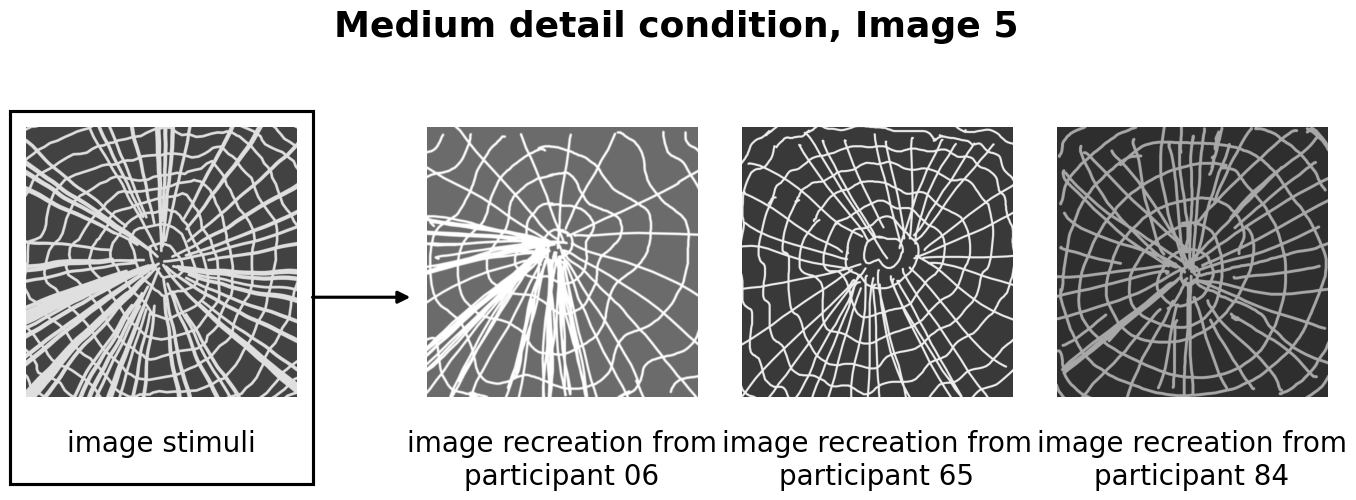

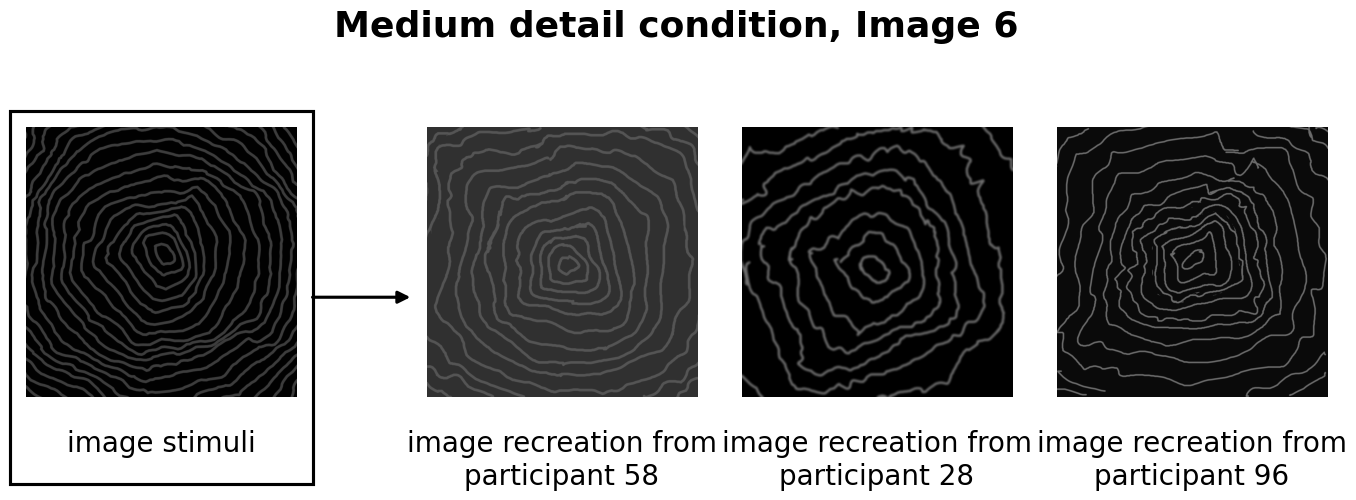

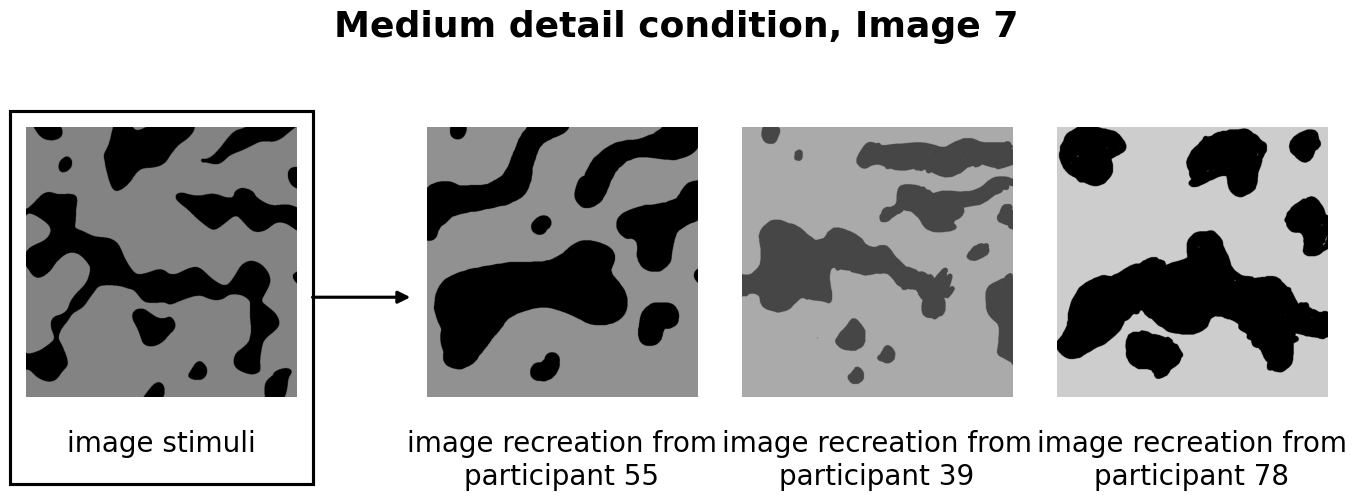

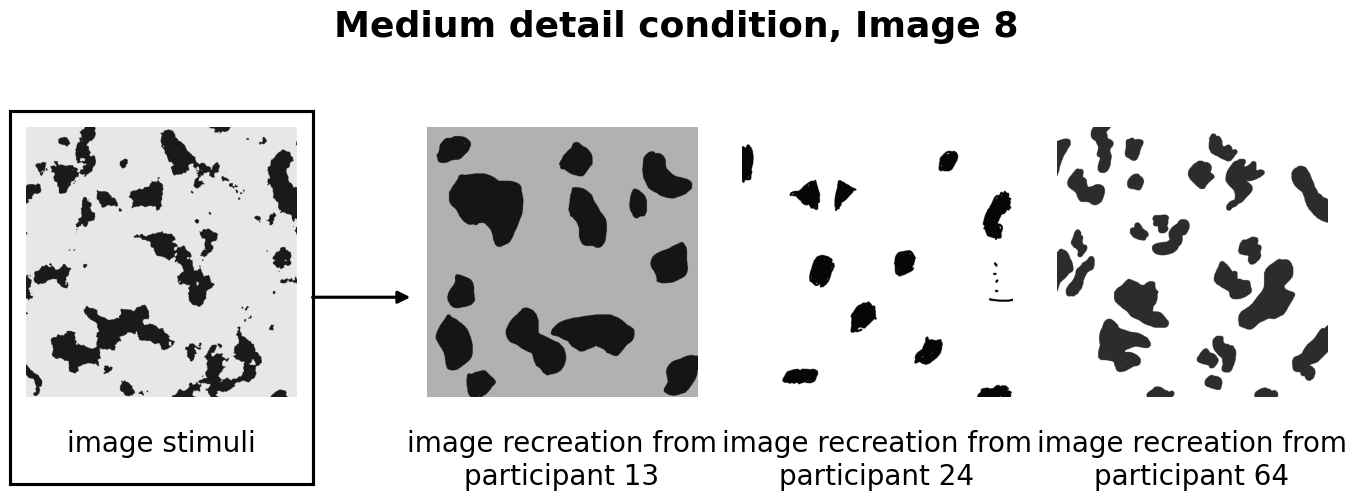

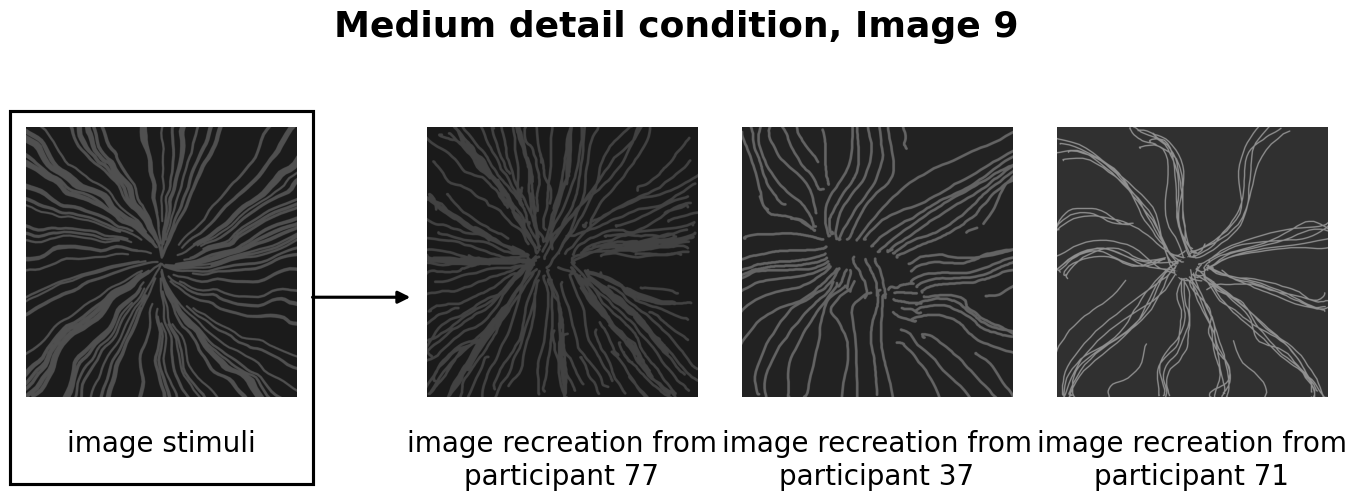

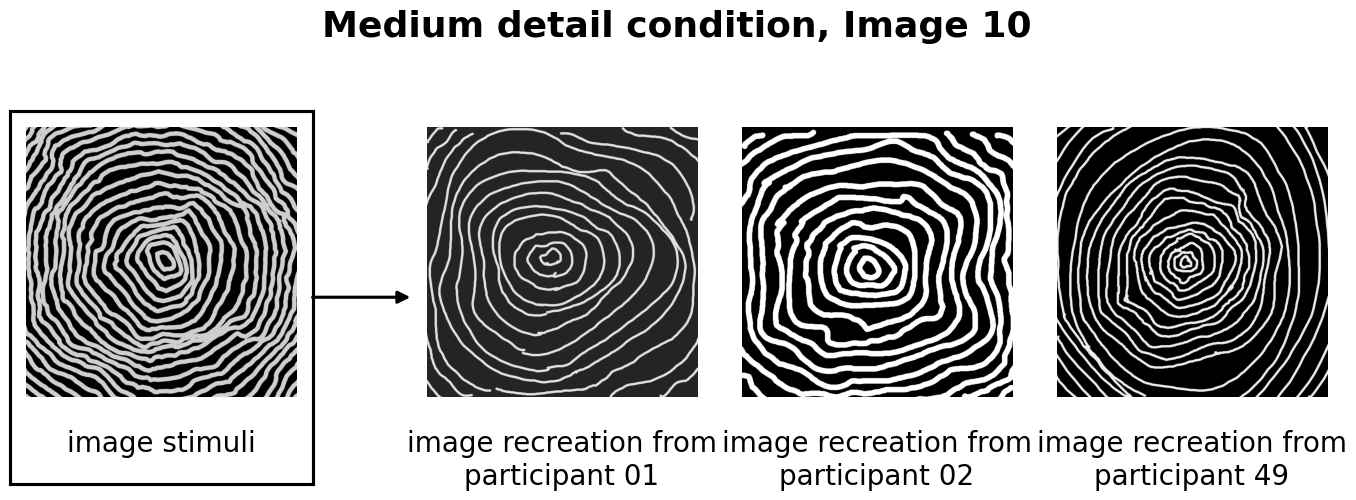

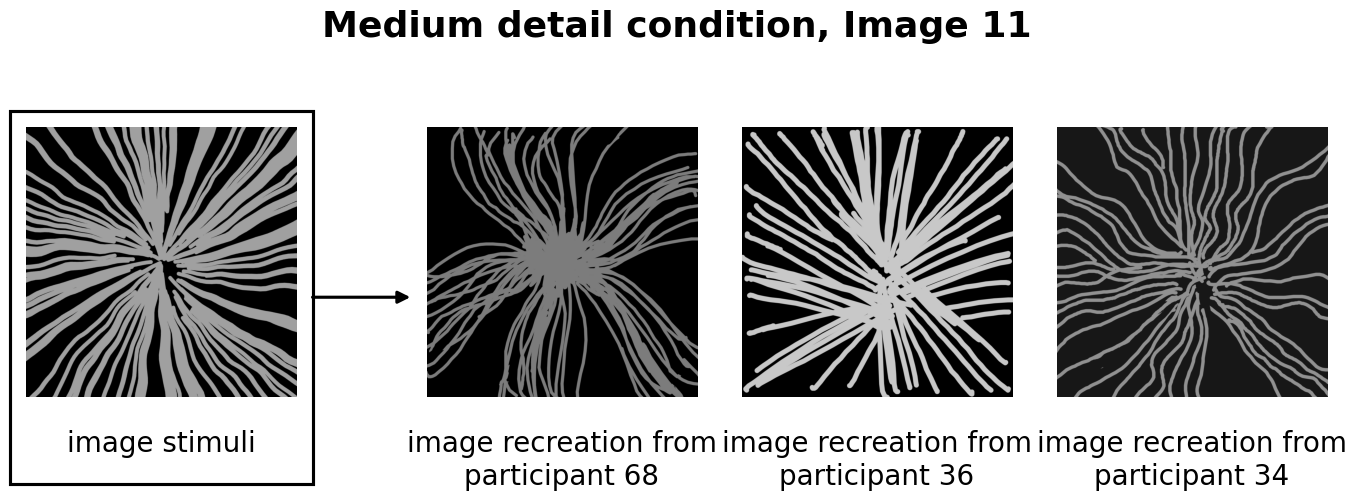

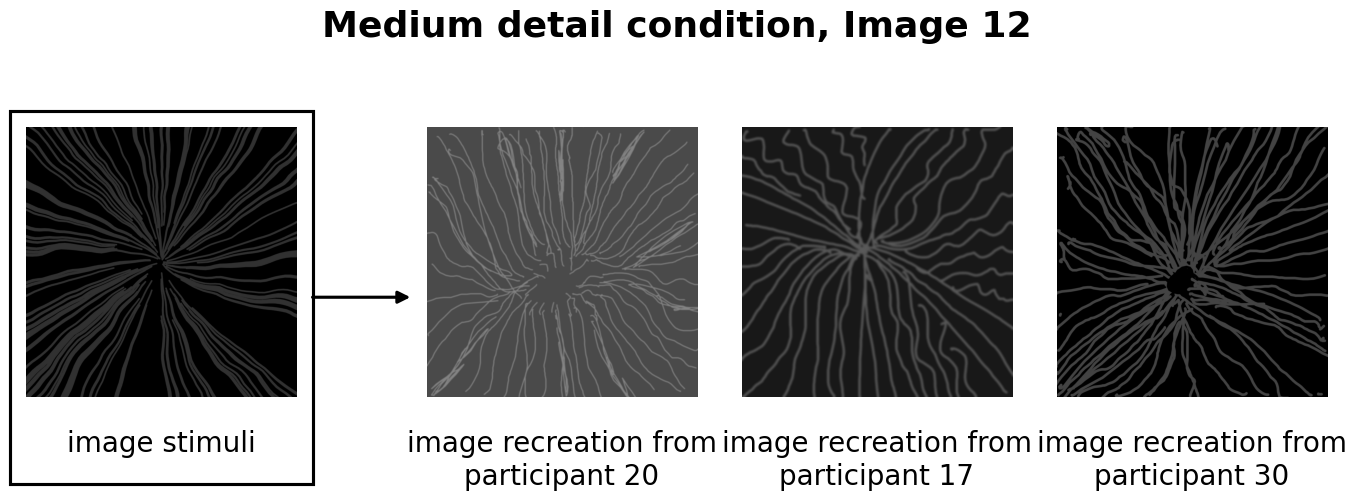

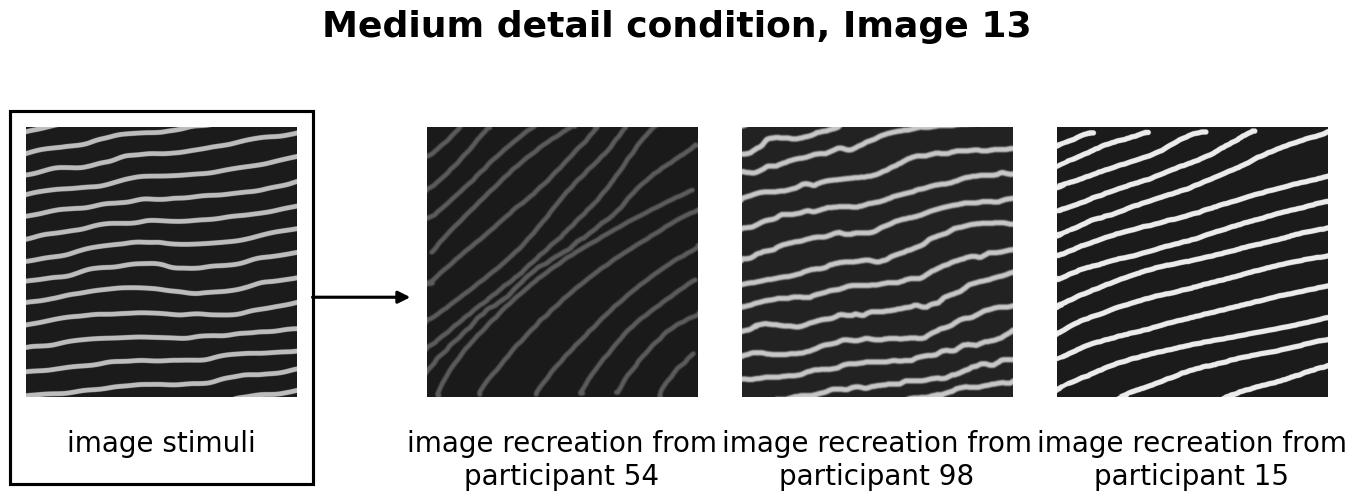

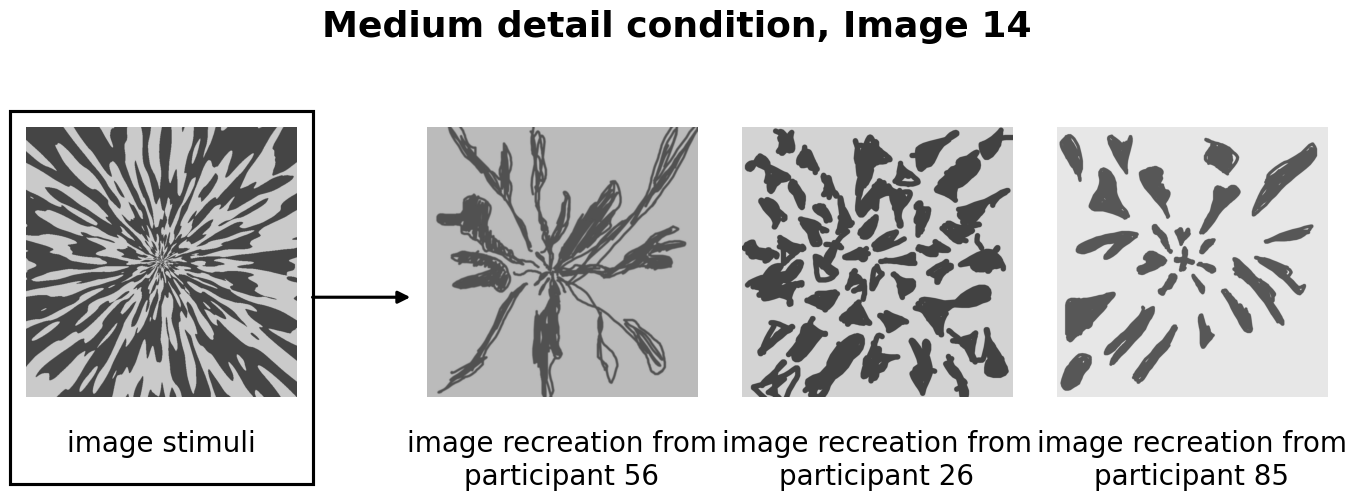

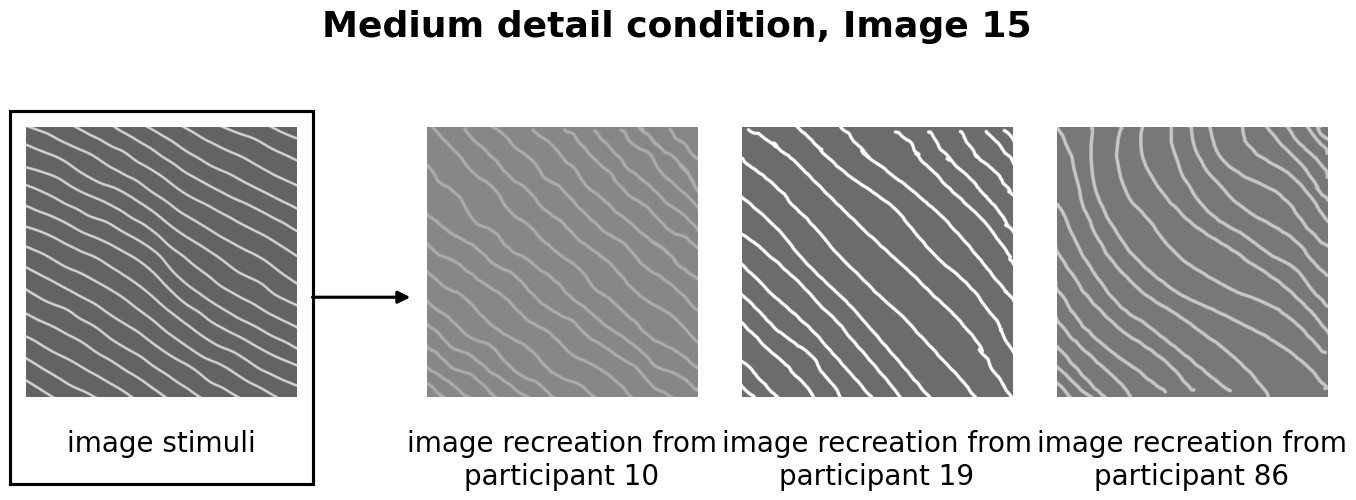

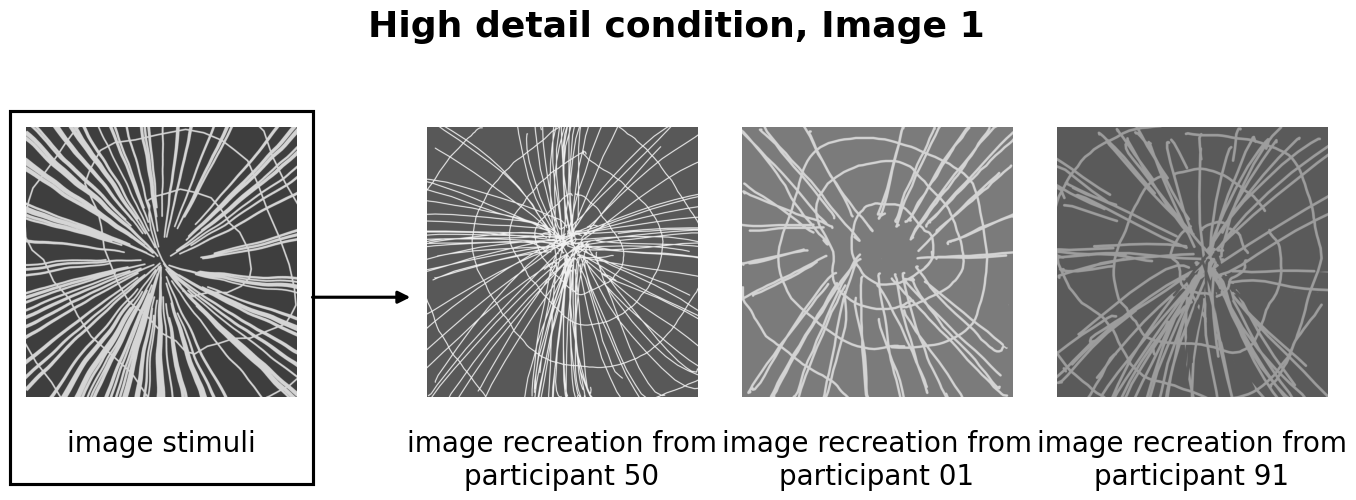

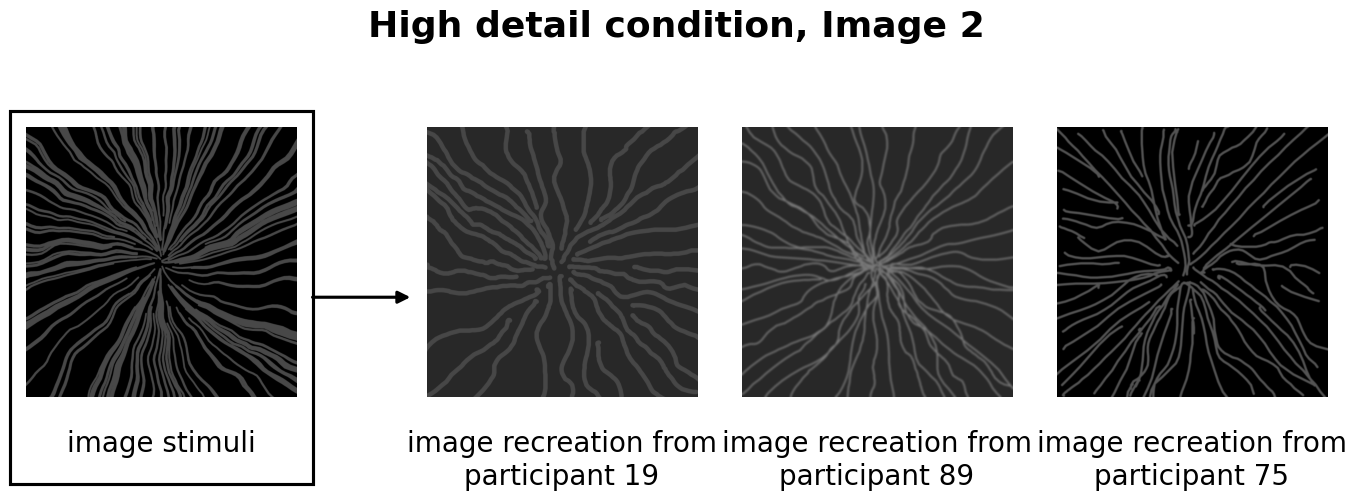

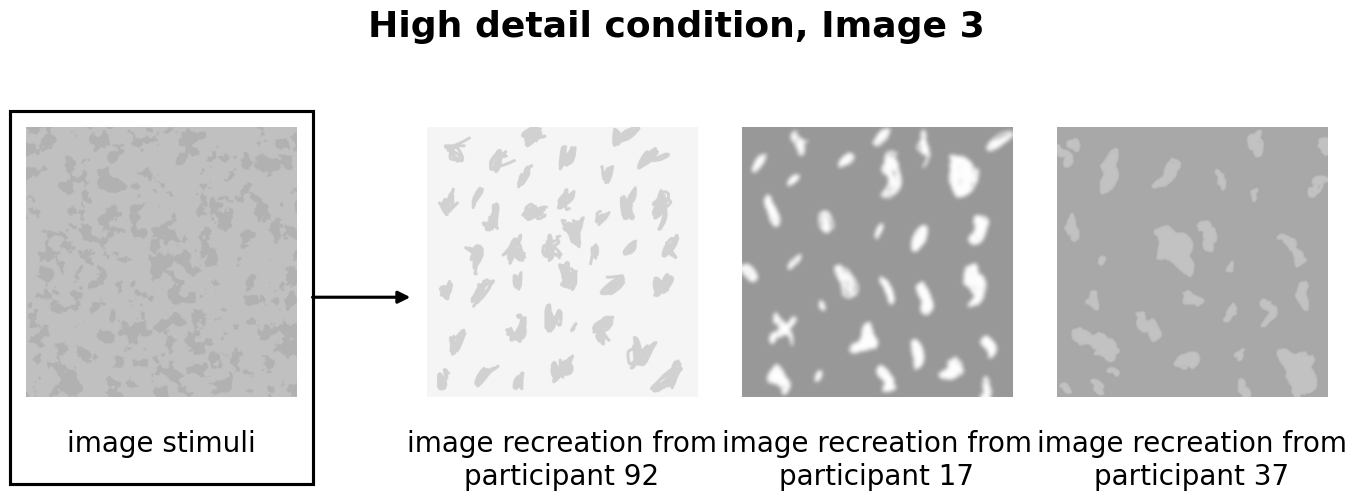

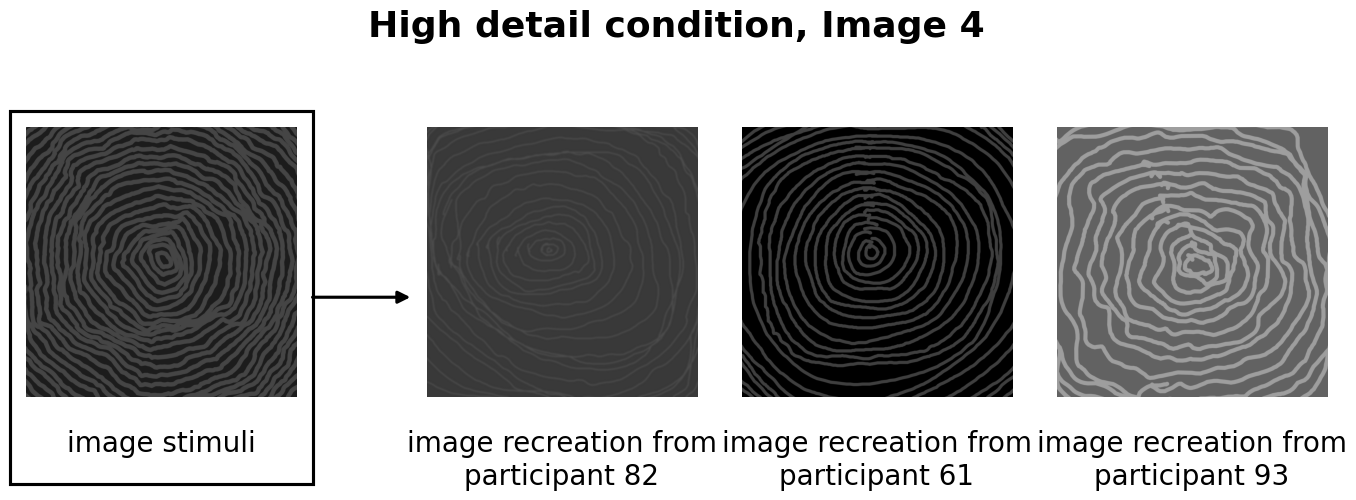

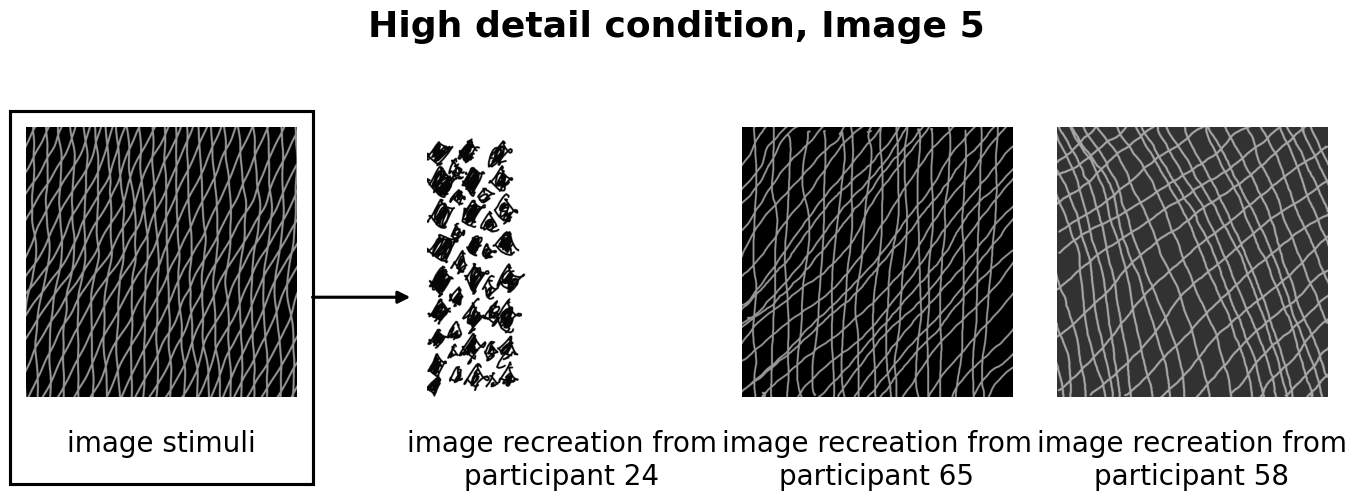

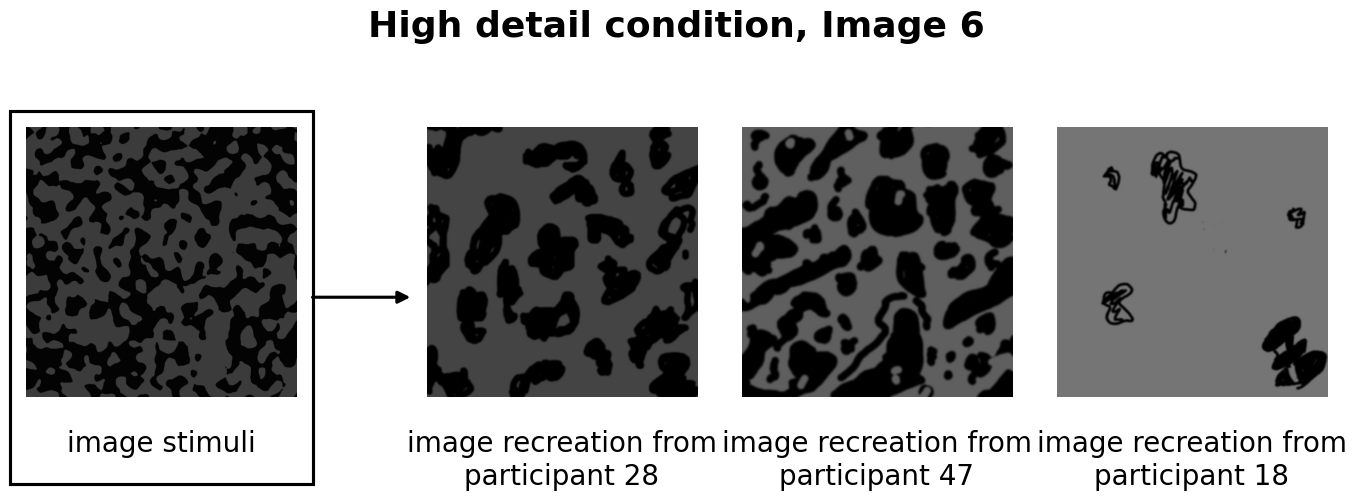

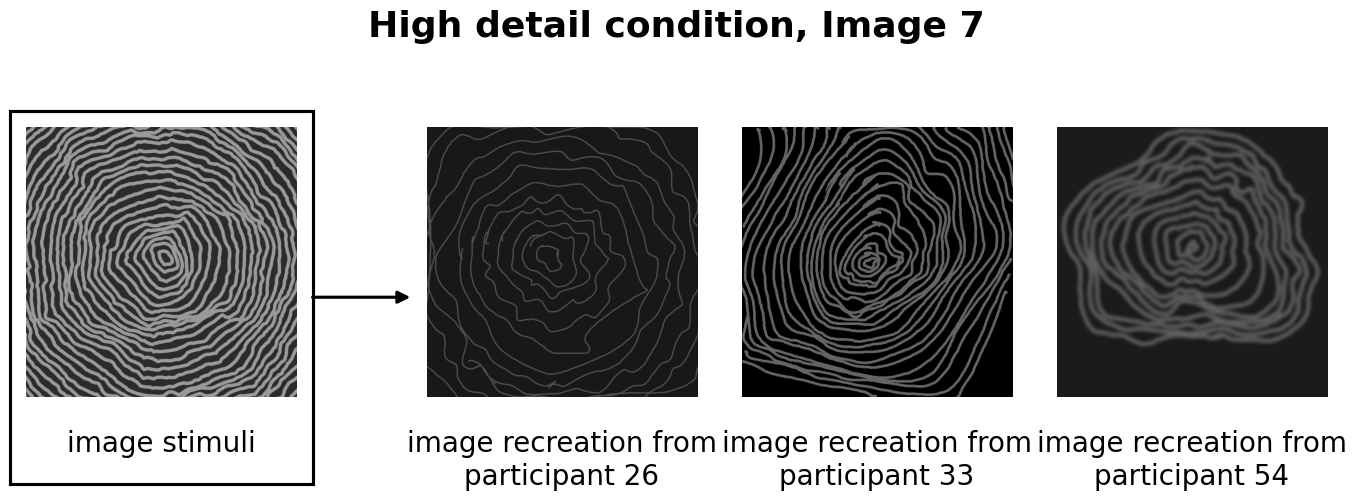

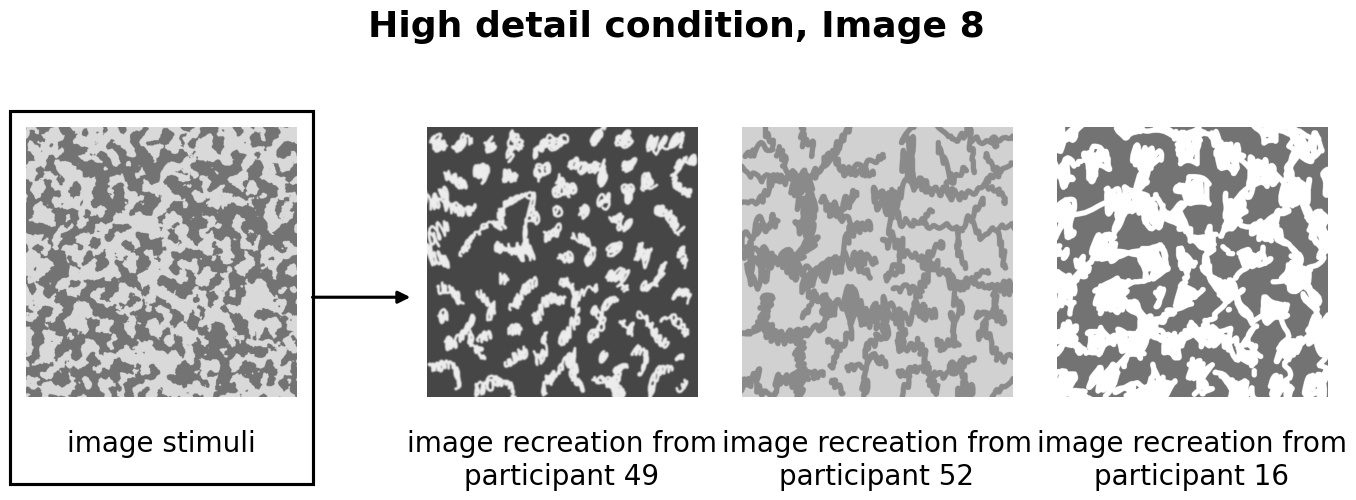

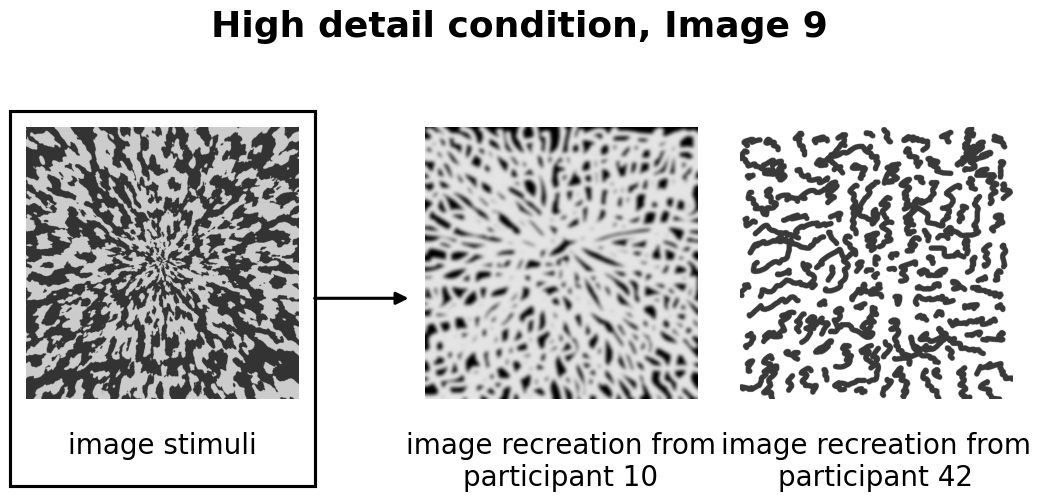

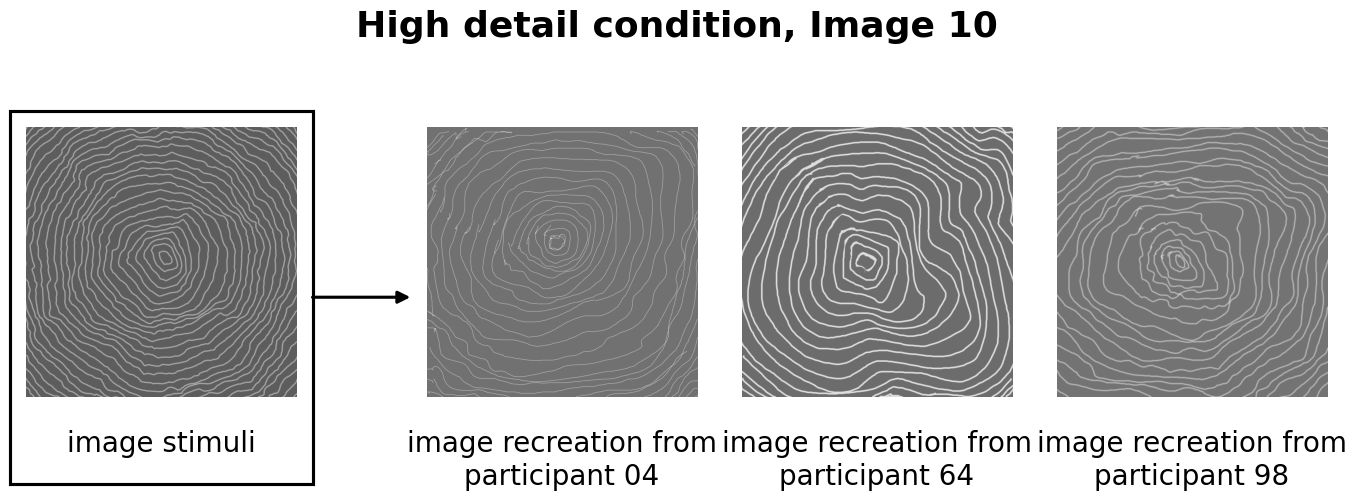

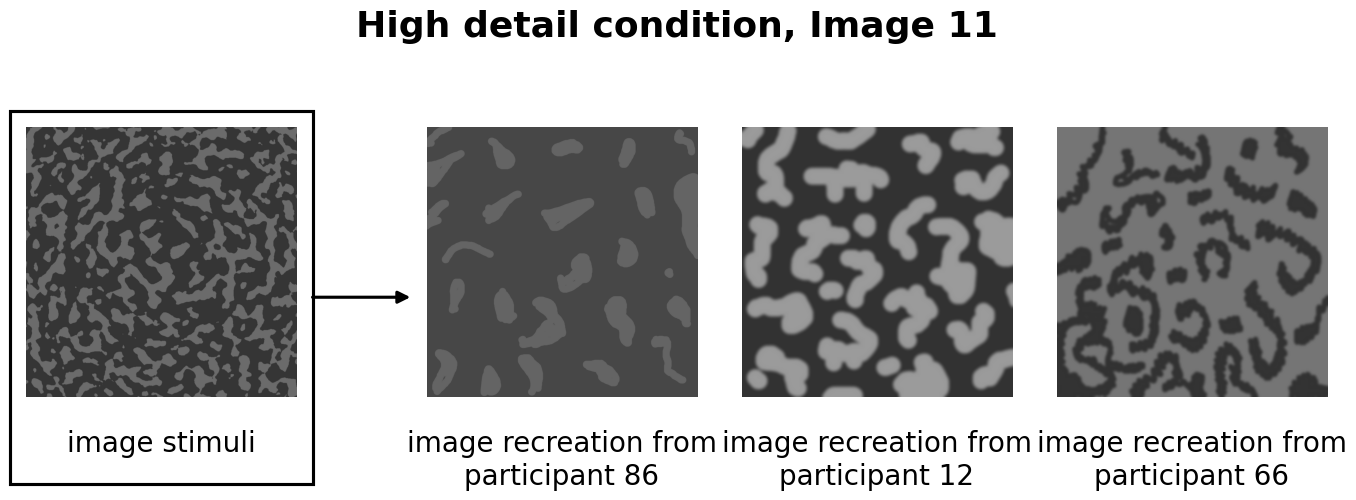

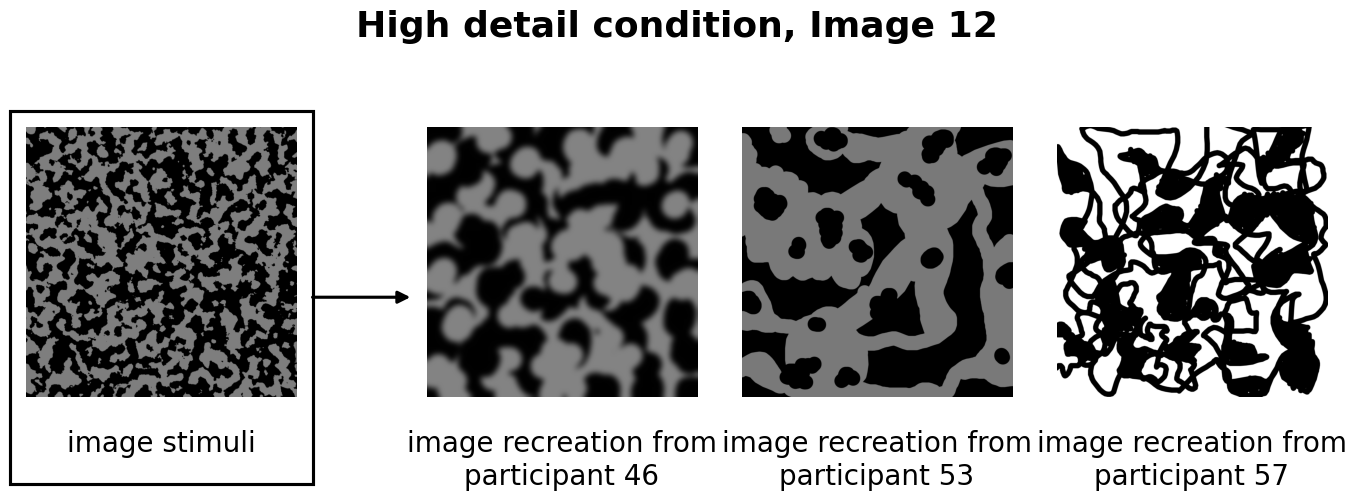

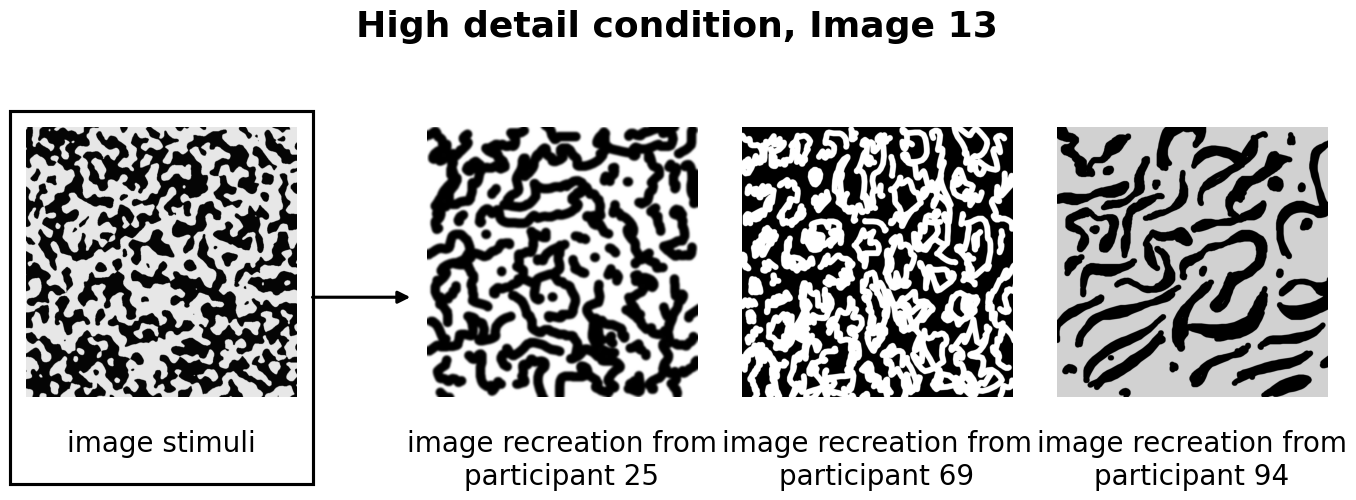

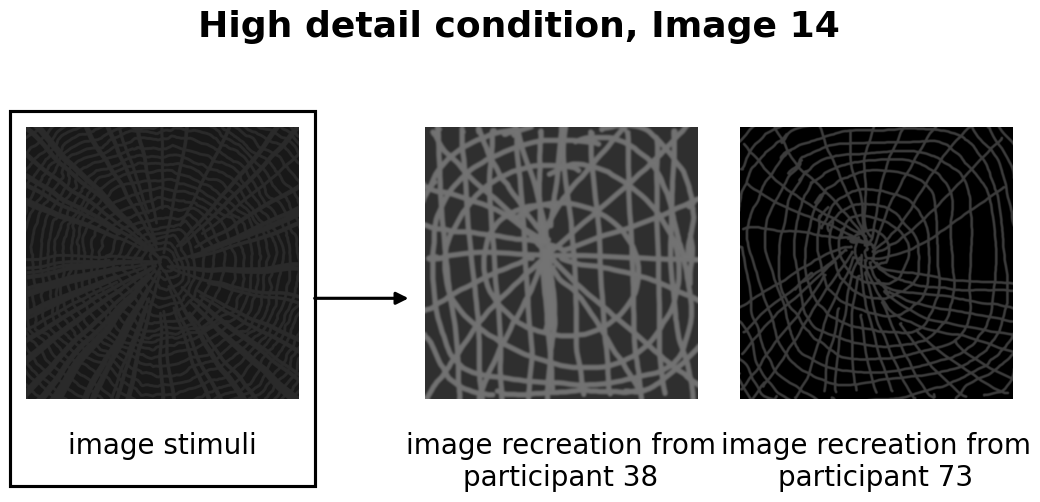

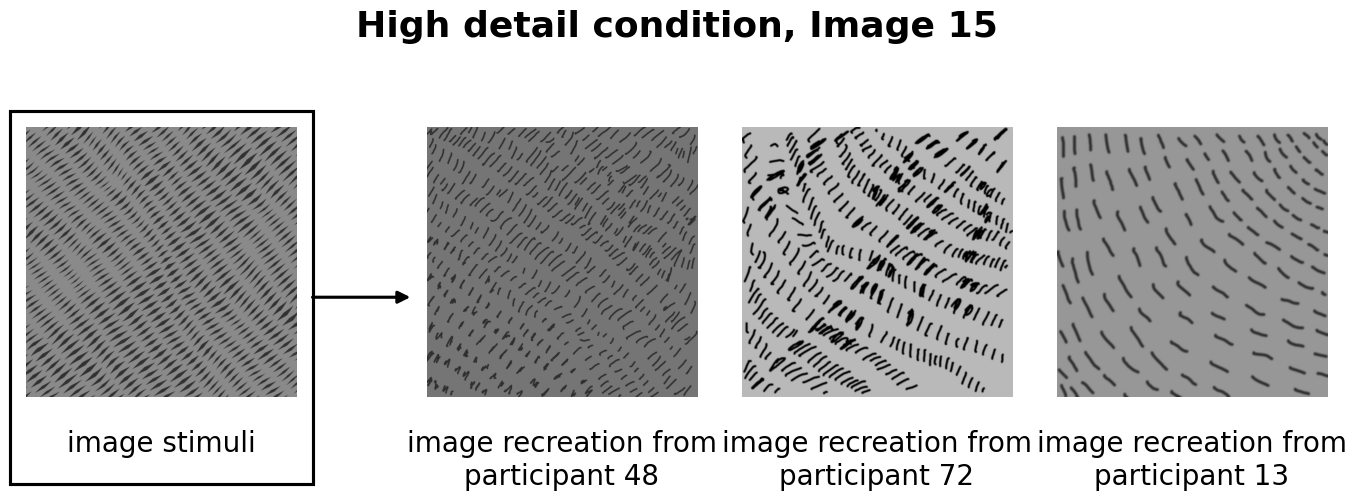

In [4]:
import os
import re
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

# ==========================================
# CONFIGURABLE PARAMETERS
# ==========================================
MAX_RECREATIONS = 3        # Cap the number of reconstructions (None for all)
SPACER_WIDTH = 0.15        # Width of the arrow/gap column (Default was 0.35)
LINE_THICKNESS = 2.25      # Width for both the bounding box border and connection arrow
ARROW_HEAD_SIZE = 18       # Scale of the arrow pointer head

# Typography Scales
FONT_SIZE_TITLE = 26       # Main figure title size
FONT_SIZE_CAPTIONS = 20    # "image stimuli" and "participant ##" size

# Paths relative to [project folder]/010_notebooks
TARGETS_DIR = os.path.join("..", "007_targets")
DATA_DIR = os.path.join("..", "005_cleaned_data")

# ==========================================
# EXECUTION LOGIC
# ==========================================
CONDITION_MAP = {
    'A': 'Low detail condition',
    'B': 'Medium detail condition',
    'C': 'High detail condition'
}

target_files = sorted(glob.glob(os.path.join(TARGETS_DIR, "[A-C][0-9][0-9].png")))

for target_path in target_files:
    target_name = os.path.basename(target_path)
    stimulus_id = os.path.splitext(target_name)[0]
    
    cond_char = stimulus_id[0]
    img_display_num = int(stimulus_id[1:]) + 1
    
    condition_name = CONDITION_MAP.get(cond_char, "Unknown condition")
    main_title = f"{condition_name}, Image {img_display_num}"
    
    search_pattern = os.path.join(DATA_DIR, f"*__trialT_{stimulus_id}__*")
    recreation_files = glob.glob(search_pattern)
    
    recreations = []
    for rec_path in recreation_files:
        rec_name = os.path.basename(rec_path)
        part_match = re.search(r'__participant_P3(\d{2})__', rec_name)
        if part_match:
            part_id = part_match.group(1)
            recreations.append((part_id, rec_path))
    
    if MAX_RECREATIONS is not None and len(recreations) > MAX_RECREATIONS:
        recreations = random.sample(recreations, MAX_RECREATIONS)
    else:
        recreations.sort(key=lambda x: x[0])
        
    num_recreations = len(recreations)
    if num_recreations == 0:
        continue
        
    # Layout allocation
    total_cols = 1 + 1 + num_recreations
    width_ratios = [1.0, SPACER_WIDTH] + [1.0] * num_recreations
    
    fig = plt.figure(figsize=(3.5 * (1 + num_recreations) + (SPACER_WIDTH * 3), 5.5))
    gs = fig.add_gridspec(1, total_cols, width_ratios=width_ratios)
    
    # 1. Plot Image Stimulus
    ax_stim = fig.add_subplot(gs[0, 0])
    stim_img = mpimg.imread(target_path)
    ax_stim.imshow(stim_img)
    ax_stim.axis('off')
    
    ax_stim.text(0.5, -0.12, "image stimuli\n ", transform=ax_stim.transAxes, 
                 ha='center', va='top', fontsize=FONT_SIZE_CAPTIONS, color='black')
    
    box = mpatches.Rectangle(
        xy=(-0.06, -0.32), 
        width=1.12, 
        height=1.38, 
        fill=False, 
        edgecolor='black', 
        lw=LINE_THICKNESS, 
        clip_on=False, 
        transform=ax_stim.transAxes
    )
    ax_stim.add_patch(box)
    
    # 2. Blank Spacer Axis
    ax_spacer = fig.add_subplot(gs[0, 1])
    ax_spacer.axis('off')
    
    # 3. Plot Image Recreations
    axes_recs = []
    for idx, (part_id, rec_path) in enumerate(recreations):
        ax_rec = fig.add_subplot(gs[0, 2 + idx])
        rec_img = mpimg.imread(rec_path)
        ax_rec.imshow(rec_img)
        ax_rec.axis('off')
        
        ax_rec.text(0.5, -0.12, f"image recreation from\nparticipant {part_id}", 
                    transform=ax_rec.transAxes, ha='center', va='top', fontsize=FONT_SIZE_CAPTIONS, color='black')
        axes_recs.append(ax_rec)
        
    # 4. Strictly Horizontal Connection Arrow
    # Uses 'figure fraction' coordinates for absolute vertical alignment parity
    arrow = mpatches.ConnectionPatch(
        xyA=(1.06, 0.37), 
        xyB=(-0.06, 0.37), 
        coordsA="axes fraction", 
        coordsB="axes fraction",
        axesA=ax_stim, 
        axesB=axes_recs[0], 
        arrowstyle="-|>", 
        lw=LINE_THICKNESS, 
        color='black', 
        mutation_scale=ARROW_HEAD_SIZE
    )
    ax_stim.add_artist(arrow)
    
    fig.suptitle(main_title, fontsize=FONT_SIZE_TITLE, fontweight='bold', y=0.96)
    
    plt.subplots_adjust(top=0.78, bottom=0.22, left=0.05, right=0.95)
    plt.show()